# 03 — TF-IDF + LinearSVC

Candidato A del TDT §7.2: paradigma vectorial interpretable como **línea base** del componente C2. Esta notebook entrena, evalúa contra el test hold-out y extrae los tokens más influyentes por clase (gancho para análisis de errores en iteraciones futuras).

**Objetivo cuantitativo:** F1-macro substancialmente por encima del majority baseline (~0.23). Resultados publicados sobre NLBSE'23 con baselines clásicos rondan 0.75–0.82 (TDT §8.1).

## 1. Bootstrap

In [1]:
REPO_URL = 'https://github.com/elvinsomon/pln-poc.git'

import os, sys, subprocess
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.isdir('/content/pln-poc'):
        subprocess.run(['git', 'clone', REPO_URL, '/content/pln-poc'], check=True)
    os.chdir('/content/pln-poc')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
else:
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')

PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import joblib
from pathlib import Path
from src.utils.colab import setup_environment, bootstrap_dataset
from src.utils.config import load_config
from src.data.splits import prepare_splits, load_splits
from src.models.tfidf_svm import build_pipeline, extract_top_features
from src.evaluation.metrics import compute_metrics, save_metrics, plot_confusion

setup_environment(seed=42, project_root=PROJECT_ROOT)
cfg_data = load_config('data.yaml')
cfg = load_config('tfidf_svm.yaml')
labels = cfg['classes']
bootstrap_dataset(cfg_data)
print('cwd:', os.getcwd())

cwd: /Users/elvinsomon/Documents/US/2doCuatrimestre/Procesamiento del Lenguaje Natural (PLN)/Tarea02/PoC-C2


## 2. Cargar splits

In [2]:
prepare_splits(cfg_data, project_root=PROJECT_ROOT)   # idempotente
splits = load_splits(cfg_data, project_root=PROJECT_ROOT)
for name, df in splits.items():
    print(f'{name:5s} n={len(df):>6,}  dist={df["label"].value_counts().to_dict()}')

train n=24,000  dist={'question': 8000, 'feature': 8000, 'bug': 8000}
val   n= 3,000  dist={'bug': 1000, 'feature': 1000, 'question': 1000}
test  n= 3,000  dist={'question': 1000, 'feature': 1000, 'bug': 1000}


## 3. Entrenar pipeline default

In [3]:
pipeline = build_pipeline(cfg)
pipeline.fit(splits['train']['text'], splits['train']['label'])

y_val_pred = pipeline.predict(splits['val']['text'])
val_metrics = compute_metrics(splits['val']['label'], y_val_pred, labels=labels)
print('VAL · accuracy :', round(val_metrics['accuracy'], 4))
print('VAL · f1_macro :', round(val_metrics['f1_macro'], 4))

VAL · accuracy : 0.7713
VAL · f1_macro : 0.7711


## 4. (Opcional) Grid manual

Activar `grid_search.enabled: true` en `configs/tfidf_svm.yaml` para barrer C y ngram_range. Para esta iteración basta el default — el grid se documenta abajo como referencia.

```python
# from itertools import product
# results = []
# for C, ng in product(cfg['grid_search']['C'], cfg['grid_search']['ngram_range']):
#     cfg_g = {**cfg, 'classifier': {**cfg['classifier'], 'C': C},
#                       'vectorizer': {**cfg['vectorizer'], 'ngram_range': ng}}
#     p = build_pipeline(cfg_g).fit(splits['train']['text'], splits['train']['label'])
#     m = compute_metrics(splits['val']['label'], p.predict(splits['val']['text']), labels)
#     results.append({'C': C, 'ngram': tuple(ng), 'f1_macro': m['f1_macro']})
# pd.DataFrame(results)
```

## 5. Evaluación en test

              precision    recall  f1-score   support

         bug     0.7732    0.8150    0.7936      1000
     feature     0.8029    0.8230    0.8128      1000
    question     0.7991    0.7360    0.7663      1000

    accuracy                         0.7913      3000
   macro avg     0.7918    0.7913    0.7909      3000
weighted avg     0.7918    0.7913    0.7909      3000

TEST · accuracy : 0.7913
TEST · f1_macro : 0.7909


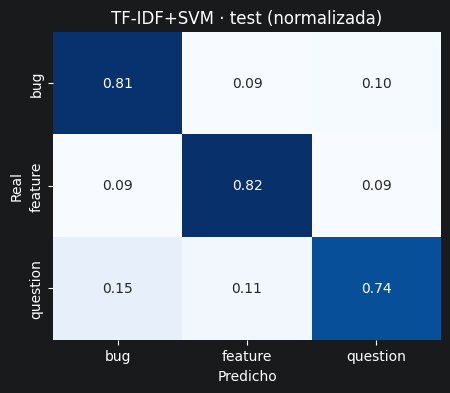

In [4]:
y_test_pred = pipeline.predict(splits['test']['text'])
test_metrics = compute_metrics(splits['test']['label'], y_test_pred, labels=labels)
print(test_metrics['report'])
print('TEST · accuracy :', round(test_metrics['accuracy'], 4))
print('TEST · f1_macro :', round(test_metrics['f1_macro'], 4))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(test_metrics['confusion_matrix']['matrix'], labels=labels, ax=ax, normalize=True)
ax.set_title('TF-IDF+SVM · test (normalizada)')
plt.show()

## 6. Interpretabilidad: top tokens por clase

In [5]:
top = extract_top_features(pipeline, k=20)
for cls in labels:
    print(f'\n=== {cls} ===')
    print(top[top['class'] == cls][['rank', 'token', 'weight']].to_string(index=False))


=== bug ===
 rank         token   weight
    1           bug 7.102637
    2           fix 2.892698
    3        broken 2.480149
    4           not 2.364431
    5     reproduce 2.290165
    6          when 2.262090
    7      happened 2.217438
    8     incorrect 2.150369
    9         wrong 2.132387
   10         fails 2.073047
   11         doesn 1.956598
   12       crashes 1.906416
   13         shows 1.886164
   14         twice 1.824070
   15      expected 1.800271
   16 what happened 1.778275
   17      affected 1.762162
   18      does not 1.713016
   19       failing 1.678396
   20        grafik 1.672911

=== feature ===
 rank               token   weight
    1                 add 4.725176
    2             feature 4.105641
    3         enhancement 3.225925
    4             improve 3.167668
    5               allow 2.498147
    6              create 2.359622
    7             support 2.318025
    8         improvement 2.281195
    9           implement 2.078774
   10      

## 7. Persistencia (modelo + métricas)

In [6]:
models_dir = Path(cfg['paths']['models'])
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / 'tfidf_svm.joblib'
joblib.dump(pipeline, model_path)

save_metrics({'val': val_metrics, 'test': test_metrics},
             f"{cfg['paths']['metrics']}/tfidf_svm.json")
top.to_csv(f"{cfg['paths']['reports']}/tfidf_svm_top_tokens.csv", index=False)
print('saved:', model_path)

saved: models/tfidf_svm.joblib


## 8. Interpretación

- Tokens top de `bug`: esperamos `error`, `crash`, `fail`, códigos HTTP, `<CODE>` (placeholder del code-fence tras limpieza).
- Tokens top de `feature`: `add`, `support`, `would be nice`, `request`.
- Tokens top de `question`: marcadores interrogativos (`how`, `why`, `?`).
- Pares confusos esperados (TDT §2.1, nivel pragmático): `bug ↔ question` (vocabulario técnico compartido) y `feature ↔ question` (frontera ilocutiva). Estos errores serán el punto de partida del análisis lingüístico de la siguiente iteración.